# TimescaleDB: Hierarchical Spatial Rollup — Minimal Example

1. Create `patch` (regular table) and `pred_patch` (TimescaleDB hypertable)
2. Define Z-order Morton SQL helper functions
3. Insert **N** initial rows and run a single full refresh across all aggregate levels
4. Verify that row counts decrease and `SUM(patch_count)` is conserved at every level
5. Insert **M** new rows and run a targeted incremental refresh on the dirty time window
6. Confirm that every level's total grew by exactly **M**

In [1]:
import psycopg2
import time

DATABASE_URL = "dbname=testdb user=testuser password=mypassword host=prototyping-tsdb-1"
N_ROWS = 100_000  # number of rows to insert into each table

conn = psycopg2.connect(DATABASE_URL)
conn.autocommit = False
cur = conn.cursor()

# Verify TimescaleDB is available
cur.execute("SELECT extversion FROM pg_extension WHERE extname = 'timescaledb';")
row = cur.fetchone()
print(f"TimescaleDB version: {row[0] if row else 'NOT INSTALLED'}")

TimescaleDB version: 2.25.2


## 1. Create Tables

- **`patch`** — regular table holding ground-truth labels per patch.  
- **`pred_patch`** — TimescaleDB hypertable partitioned by `event_ts`, holding per-inference predictions.

In [2]:
# ── Drop existing objects (clean slate) ──────────────────────────────────────
# Drop all CAgg views first (reverse dependency order: coarsest → finest)
cur.execute("DROP MATERIALIZED VIEW IF EXISTS pred_patch_label_agg_l0 CASCADE;")
cur.execute("DROP MATERIALIZED VIEW IF EXISTS pred_patch_label_agg_l1 CASCADE;")
cur.execute("DROP MATERIALIZED VIEW IF EXISTS pred_patch_label_agg_l3 CASCADE;")
cur.execute("DROP MATERIALIZED VIEW IF EXISTS pred_patch_label_agg_l5 CASCADE;")
# Now safe to drop the functions (no views depend on them anymore)
cur.execute("DROP FUNCTION IF EXISTS cell_to_parent(BIGINT, INT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_encode(BIGINT, BIGINT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_decode_j(BIGINT) CASCADE;")
cur.execute("DROP FUNCTION IF EXISTS morton_decode_i(BIGINT) CASCADE;")
cur.execute("DROP TABLE IF EXISTS pred_patch CASCADE;")
cur.execute("DROP TABLE IF EXISTS patch CASCADE;")
conn.commit()


In [3]:

# ── patch table (regular) ─────────────────────────────────────────────────────
cur.execute("""
    CREATE TABLE patch (
        id          BIGSERIAL    PRIMARY KEY,
        patch_uid   INT          NOT NULL UNIQUE,
        gt_label    INT,
        event_ts    TIMESTAMPTZ  NOT NULL DEFAULT NOW(),
        image_id    INT,
        working_mag FLOAT
    );
""")

# ── pred_patch table (will become a hypertable) ───────────────────────────────
# grid_cell_id is BIGINT to hold the 64-bit Z-order encoded cell index
cur.execute("""
    CREATE TABLE pred_patch (
        id           BIGSERIAL   NOT NULL,
        patch_uid    BIGINT      NOT NULL,
        embed_coords POINT,
        grid_cell_id BIGINT,
        event_ts     TIMESTAMPTZ NOT NULL DEFAULT NOW(),
        pred_label   INT,
        patch_coords POINT,
        PRIMARY KEY (id, event_ts)          -- event_ts must be in the PK for hypertable
    );
""")
conn.commit()

# ── Convert pred_patch to a TimescaleDB hypertable ────────────────────────────
cur.execute("""
    SELECT create_hypertable('pred_patch', 'event_ts', chunk_time_interval => INTERVAL '1 day');
""")
conn.commit()
print("Tables created. pred_patch is now a hypertable partitioned on event_ts.")

Tables created. pred_patch is now a hypertable partitioned on event_ts.


## 2. Insert N Rows (Initial Dataset)

`patch_uid` values 1–N are shared across both tables so they can be joined by the continuous aggregate.

In [4]:
# ── Insert N_ROWS rows into patch ────────────────────────────────────────────
# patch_uid : 1 – N_ROWS
# gt_label  : 0 – 4  (5 classes, deterministic via modulo so joins are meaningful)
# image_id  : 1 – 10
# working_mag: 10.0 / 20.0 / 40.0 cycling
# event_ts  : spread over the last 30 days

start = time.time()
cur.execute(f"""
    INSERT INTO patch (patch_uid, gt_label, event_ts, image_id, working_mag)
    SELECT
        gs                                                   AS patch_uid,
        1                                               AS gt_label,
        NOW() - (random() * INTERVAL '30 days')             AS event_ts,
        (gs % 10) + 1                                        AS image_id,
        CASE (gs % 3)
            WHEN 0 THEN 10.0
            WHEN 1 THEN 20.0
            ELSE        40.0
        END                                                  AS working_mag
    FROM generate_series(1, {N_ROWS}) AS gs;
""")
conn.commit()
print(f"patch: {N_ROWS:,} rows inserted in {time.time() - start:.3f}s")

patch: 100,000 rows inserted in 0.378s


In [5]:

import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')

import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
from utils import HierarchicalGridIndexZOrder

# ── Insert N_ROWS rows into pred_patch ──────────────────────────────────────
# embed_coords : Gaussian, centred at (50, 50), std=15, clamped to [0, 100)
# grid_cell_id : Z-order cell at level 5 via HierarchicalGridIndexZOrder
#                  cell_size=1.0 → level-5 cell width = 1/32 ≈ 0.03125 units
#                  The embed space [0,100) spans 3200 level-5 cells per axis.
# patch_coords : uniform in [0, 1000) × [0, 1000)
# event_ts     : ALL within a single 1-hour bucket (no multi-bucket spread)

GRID_LEVEL = 5
grid = HierarchicalGridIndexZOrder(cell_size=1.0)

rng = np.random.default_rng(42)

# Gaussian embed coordinates, clamped to [0, 100)
ex = np.clip(rng.normal(loc=50.0, scale=15.0, size=N_ROWS), 0.0, 99.9999)
ey = np.clip(rng.normal(loc=50.0, scale=15.0, size=N_ROWS), 0.0, 99.9999)

# Compute grid_cell_id for each point using the Python grid class
grid_cell_ids = np.array([
    grid.point_to_cell(float(x), float(y), GRID_LEVEL)
    for x, y in zip(ex, ey)
], dtype=np.int64)

patch_uids  = np.arange(1, N_ROWS + 1, dtype=np.int64)
# pred_labels = patch_uids % 5
pred_labels = np.ones(N_ROWS, dtype=np.int64)  # single-class for simpler sanity checks

px = rng.uniform(0, 1000, size=N_ROWS)
py = rng.uniform(0, 1000, size=N_ROWS)

now = datetime.now(timezone.utc)
# Pin all timestamps to the same 1-hour bucket so every row lands in one bucket
bucket_start = now.replace(minute=0, second=0, microsecond=0)
event_ts = [bucket_start + timedelta(seconds=rng.uniform(0, 3599)) for _ in range(N_ROWS)]

# Batch insert via executemany
start = time.time()
rows = [
    (int(patch_uids[i]),
     f"({ex[i]},{ey[i]})",
     int(grid_cell_ids[i]),
     event_ts[i],
     int(pred_labels[i]),
     f"({px[i]},{py[i]})")
    for i in range(N_ROWS)
]

cur.executemany("""
    INSERT INTO pred_patch (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    VALUES (%s, %s::point, %s, %s, %s, %s::point)
""", rows)
conn.commit()
print(f"pred_patch: {N_ROWS:,} rows inserted in {time.time() - start:.3f}s  (Gaussian, Python-generated)")
print(f"  All event_ts in bucket: {bucket_start}  →  {bucket_start + timedelta(hours=1)}")

# Quick sanity check
cur.execute("SELECT COUNT(*) FROM patch;")
print(f"  patch row count      : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(*) FROM pred_patch;")
print(f"  pred_patch row count : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(DISTINCT grid_cell_id) FROM pred_patch;")
print(f"  distinct level-{GRID_LEVEL} cells : {cur.fetchone()[0]:,}")
cur.execute("SELECT COUNT(DISTINCT time_bucket('1 hour', event_ts)) FROM pred_patch;")
print(f"  distinct buckets     : {cur.fetchone()[0]:,}  (should be 1)")

# Show hypertable chunks
cur.execute("""
    SELECT chunk_name, range_start, range_end
    FROM timescaledb_information.chunks
    WHERE hypertable_name = 'pred_patch'
    ORDER BY range_start;
""")
chunks = cur.fetchall()
print(f"\npred_patch hypertable chunks ({len(chunks)} total):")
for c in chunks:
    print(f"  {c[0]}  {c[1]}  →  {c[2]}")


pred_patch: 100,000 rows inserted in 23.359s  (Gaussian, Python-generated)
  All event_ts in bucket: 2026-03-05 23:00:00+00:00  →  2026-03-06 00:00:00+00:00
  patch row count      : 100,000
  pred_patch row count : 100,000
  distinct level-5 cells : 98,244
  distinct buckets     : 1  (should be 1)

pred_patch hypertable chunks (1 total):
  _hyper_108_272_chunk  2026-03-05 00:00:00+00:00  →  2026-03-06 00:00:00+00:00


## 3. Continuous Aggregate (Level 5 — Finest)

Create the base TimescaleDB continuous aggregate joining `pred_patch` with `patch`.

- **`WITH NO DATA`** — the view is created empty; data is populated by an explicit `CALL refresh_continuous_aggregate(...)`.
- **No automatic refresh policy** — all refreshes are triggered manually.
- `materialized_only = true` — queries only see pre-materialised rows; no silent fallback to real-time re-aggregation.

JOINs with regular (non-hypertable) tables are supported since TimescaleDB 2.9.

In [6]:
# ── Create the base continuous aggregate (level 5, finest spatial resolution) ──
# WITH NO DATA: the view is created but not populated yet.
# No refresh policy is registered — all refreshes are triggered manually.
cur.execute("""
    CREATE MATERIALIZED VIEW pred_patch_label_agg_l5
    WITH (timescaledb.continuous, timescaledb.materialized_only = true) AS
    SELECT
        time_bucket('1 hour', pp.event_ts)     AS bucket,
        pp.pred_label,
        p.gt_label,
        pp.grid_cell_id,
        COUNT(*)                               AS patch_count
    FROM pred_patch  pp
    JOIN patch       p  ON p.patch_uid = pp.patch_uid
    GROUP BY 1, 2, 3, 4
    WITH NO DATA;
""")
conn.commit()
print("Base continuous aggregate 'pred_patch_label_agg_l5' created (unpopulated).")

Base continuous aggregate 'pred_patch_label_agg_l5' created (unpopulated).


## 4. Morton SQL Helper Functions

Pure-SQL implementations of the Z-order (Morton) encode/decode and `cell_to_parent` operations,
mirroring `HierarchicalGridIndexZOrder` in `utils.py`.

These are `IMMUTABLE` functions so the continuous aggregates can call them inline without any per-row overhead.

| Function | Purpose |
|---|---|
| `morton_decode_i(code)` | Extract i (column) coordinate from a 58-bit Morton code |
| `morton_decode_j(code)` | Extract j (row) coordinate from a 58-bit Morton code |
| `morton_encode(i, j)` | Interleave i and j bits into a 58-bit Morton code |
| `cell_to_parent(cell, parent_level)` | Return the ancestor cell at a coarser resolution |

In [7]:
# TimescaleDB's refresh procedure runs with a restricted search_path
# (e.g. _timescaledb_internal, pg_catalog), so SQL functions called from a
# continuous aggregate VIEW definition must explicitly pin search_path = public
# to ensure their own sub-function calls resolve correctly during inlining.

# ── Morton decode: extract i (even bits 0,2,4,...,56) ────────────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_decode_i(code BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((code >>  0) & 1)
        | (((code >>  2) & 1) <<  1) | (((code >>  4) & 1) <<  2)
        | (((code >>  6) & 1) <<  3) | (((code >>  8) & 1) <<  4)
        | (((code >> 10) & 1) <<  5) | (((code >> 12) & 1) <<  6)
        | (((code >> 14) & 1) <<  7) | (((code >> 16) & 1) <<  8)
        | (((code >> 18) & 1) <<  9) | (((code >> 20) & 1) << 10)
        | (((code >> 22) & 1) << 11) | (((code >> 24) & 1) << 12)
        | (((code >> 26) & 1) << 13) | (((code >> 28) & 1) << 14)
        | (((code >> 30) & 1) << 15) | (((code >> 32) & 1) << 16)
        | (((code >> 34) & 1) << 17) | (((code >> 36) & 1) << 18)
        | (((code >> 38) & 1) << 19) | (((code >> 40) & 1) << 20)
        | (((code >> 42) & 1) << 21) | (((code >> 44) & 1) << 22)
        | (((code >> 46) & 1) << 23) | (((code >> 48) & 1) << 24)
        | (((code >> 50) & 1) << 25) | (((code >> 52) & 1) << 26)
        | (((code >> 54) & 1) << 27) | (((code >> 56) & 1) << 28)
    )::BIGINT
$$;
""")

# ── Morton decode: extract j (odd bits 1,3,5,...,57) ─────────────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_decode_j(code BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((code >>  1) & 1)
        | (((code >>  3) & 1) <<  1) | (((code >>  5) & 1) <<  2)
        | (((code >>  7) & 1) <<  3) | (((code >>  9) & 1) <<  4)
        | (((code >> 11) & 1) <<  5) | (((code >> 13) & 1) <<  6)
        | (((code >> 15) & 1) <<  7) | (((code >> 17) & 1) <<  8)
        | (((code >> 19) & 1) <<  9) | (((code >> 21) & 1) << 10)
        | (((code >> 23) & 1) << 11) | (((code >> 25) & 1) << 12)
        | (((code >> 27) & 1) << 13) | (((code >> 29) & 1) << 14)
        | (((code >> 31) & 1) << 15) | (((code >> 33) & 1) << 16)
        | (((code >> 35) & 1) << 17) | (((code >> 37) & 1) << 18)
        | (((code >> 39) & 1) << 19) | (((code >> 41) & 1) << 20)
        | (((code >> 43) & 1) << 21) | (((code >> 45) & 1) << 22)
        | (((code >> 47) & 1) << 23) | (((code >> 49) & 1) << 24)
        | (((code >> 51) & 1) << 25) | (((code >> 53) & 1) << 26)
        | (((code >> 55) & 1) << 27) | (((code >> 57) & 1) << 28)
    )::BIGINT
$$;
""")

# ── Morton encode: interleave i (even bits) and j (odd bits) ─────────────────
cur.execute("""
CREATE OR REPLACE FUNCTION morton_encode(i BIGINT, j BIGINT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
          ((i & 1))              | ((j & 1) << 1)
        | (((i >>  1) & 1) <<  2) | (((j >>  1) & 1) <<  3)
        | (((i >>  2) & 1) <<  4) | (((j >>  2) & 1) <<  5)
        | (((i >>  3) & 1) <<  6) | (((j >>  3) & 1) <<  7)
        | (((i >>  4) & 1) <<  8) | (((j >>  4) & 1) <<  9)
        | (((i >>  5) & 1) << 10) | (((j >>  5) & 1) << 11)
        | (((i >>  6) & 1) << 12) | (((j >>  6) & 1) << 13)
        | (((i >>  7) & 1) << 14) | (((j >>  7) & 1) << 15)
        | (((i >>  8) & 1) << 16) | (((j >>  8) & 1) << 17)
        | (((i >>  9) & 1) << 18) | (((j >>  9) & 1) << 19)
        | (((i >> 10) & 1) << 20) | (((j >> 10) & 1) << 21)
        | (((i >> 11) & 1) << 22) | (((j >> 11) & 1) << 23)
        | (((i >> 12) & 1) << 24) | (((j >> 12) & 1) << 25)
        | (((i >> 13) & 1) << 26) | (((j >> 13) & 1) << 27)
        | (((i >> 14) & 1) << 28) | (((j >> 14) & 1) << 29)
        | (((i >> 15) & 1) << 30) | (((j >> 15) & 1) << 31)
        | (((i >> 16) & 1) << 32) | (((j >> 16) & 1) << 33)
        | (((i >> 17) & 1) << 34) | (((j >> 17) & 1) << 35)
        | (((i >> 18) & 1) << 36) | (((j >> 18) & 1) << 37)
        | (((i >> 19) & 1) << 38) | (((j >> 19) & 1) << 39)
        | (((i >> 20) & 1) << 40) | (((j >> 20) & 1) << 41)
        | (((i >> 21) & 1) << 42) | (((j >> 21) & 1) << 43)
        | (((i >> 22) & 1) << 44) | (((j >> 22) & 1) << 45)
        | (((i >> 23) & 1) << 46) | (((j >> 23) & 1) << 47)
        | (((i >> 24) & 1) << 48) | (((j >> 24) & 1) << 49)
        | (((i >> 25) & 1) << 50) | (((j >> 25) & 1) << 51)
        | (((i >> 26) & 1) << 52) | (((j >> 26) & 1) << 53)
        | (((i >> 27) & 1) << 54) | (((j >> 27) & 1) << 55)
        | (((i >> 28) & 1) << 56) | (((j >> 28) & 1) << 57)
    )::BIGINT
$$;
""")

# ── cell_to_parent: coarsen a Z-order cell to a lower resolution level ────────
# SET search_path ensures morton_decode_i/j and morton_encode are found even
# when called from a TimescaleDB refresh context with a restricted search_path.
cur.execute("""
CREATE OR REPLACE FUNCTION cell_to_parent(cell BIGINT, parent_level INT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    SELECT (
        (parent_level::BIGINT << 58)
        | morton_encode(
            morton_decode_i(cell & 288230376151711743::BIGINT) >> ((cell >> 58)::INT - parent_level),
            morton_decode_j(cell & 288230376151711743::BIGINT) >> ((cell >> 58)::INT - parent_level)
          )
    )
$$;
""")
conn.commit()
print("Morton SQL functions created (with search_path = public):")
print("  morton_decode_i, morton_decode_j, morton_encode, cell_to_parent")

# ── Smoke test: level-5 cell with i=3, j=2 ───────────────────────────────────
cur.execute("""
    SELECT
        cell_val,
        cell_val >> 58                                          AS level,
        morton_decode_i(cell_val & 288230376151711743::BIGINT)  AS i,
        morton_decode_j(cell_val & 288230376151711743::BIGINT)  AS j,
        cell_to_parent(cell_val, 3)                             AS parent_l3,
        cell_to_parent(cell_val, 1)                             AS parent_l1,
        cell_to_parent(cell_val, 0)                             AS parent_l0
    FROM (SELECT (5::BIGINT << 58) | morton_encode(3, 2) AS cell_val) t;
""")
r = cur.fetchone()
print(f"\nSmoke test  cell={r[0]}  level={r[1]}  i={r[2]}  j={r[3]}")
print(f"  parent@level3 = {r[4]}")
print(f"  parent@level1 = {r[5]}")
print(f"  parent@level0 = {r[6]}")

Morton SQL functions created (with search_path = public):
  morton_decode_i, morton_decode_j, morton_encode, cell_to_parent

Smoke test  cell=1441151880758558733  level=5  i=3  j=2
  parent@level3 = 864691128455135232
  parent@level1 = 288230376151711744
  parent@level0 = 0


## 5. Hierarchical Rollup Continuous Aggregates + Initial Full Refresh

Each level is a **hierarchical CAgg** built on top of the previous one.
`cell_to_parent(grid_cell_id, target_level)` maps each Z-order cell to its ancestor purely via bitwise arithmetic — no lookup table.

All views use `materialized_only = true` and **no automatic refresh policy**.  
After all four views are created (`WITH NO DATA`), a single `CALL refresh_continuous_aggregate(view, NULL, NULL)` populates each level over all time.

| View | Source | Spatial level | Time bucket |
|---|---|---|---|
| `pred_patch_label_agg_l5` | raw hypertable | 5 (finest) | 1 hour |
| `pred_patch_label_agg_l3` | l5 CAgg | 3 | 1 hour |
| `pred_patch_label_agg_l1` | l3 CAgg | 1 | 1 hour |
| `pred_patch_label_agg_l0` | l1 CAgg | 0 (coarsest) | 1 hour |

In [8]:
# ── Rollup specification ──────────────────────────────────────────────────────
# (view_name, source_view, spatial_target_level)
ROLLUP_LEVELS = [
    ("pred_patch_label_agg_l3", "pred_patch_label_agg_l5", 3),
    ("pred_patch_label_agg_l1", "pred_patch_label_agg_l3", 1),
    ("pred_patch_label_agg_l0", "pred_patch_label_agg_l1", 0),
]

# ── Drop any existing rollup views ────────────────────────────────────────────
for view_name, *_ in reversed(ROLLUP_LEVELS):
    cur.execute(f"DROP MATERIALIZED VIEW IF EXISTS {view_name} CASCADE;")
conn.commit()

# ── Create hierarchical CAggs (WITH NO DATA, no refresh policies) ─────────────
for view_name, source, tgt_level in ROLLUP_LEVELS:
    cur.execute(f"""
        CREATE MATERIALIZED VIEW {view_name}
        WITH (timescaledb.continuous, timescaledb.materialized_only = true) AS
        SELECT
            time_bucket(INTERVAL '1 hour', bucket)        AS bucket,
            pred_label,
            gt_label,
            cell_to_parent(grid_cell_id, {tgt_level})     AS grid_cell_id,
            SUM(patch_count)                               AS patch_count
        FROM {source}
        GROUP BY 1, 2, 3, 4
        WITH NO DATA;
    """)
    conn.commit()
    print(f"Created '{view_name}'  source={source}  spatial_level={tgt_level}")

# ── Single full refresh: populate all four levels from scratch ────────────────
# refresh_continuous_aggregate must run outside a transaction block
ALL_CAGG_VIEWS = ["pred_patch_label_agg_l5"] + [v for v, *_ in ROLLUP_LEVELS]

import time

conn.autocommit = True
print("\nRunning initial full refresh for all levels ...")
for view in ALL_CAGG_VIEWS:
    t0 = time.perf_counter()
    cur.execute(
        "CALL refresh_continuous_aggregate(%s, NULL, NULL);",
        (view,),
    )
    print(f"  {view:<30}  refreshed in {time.perf_counter() - t0:.3f}s")
conn.autocommit = False
print("\nAll levels populated.")

Created 'pred_patch_label_agg_l3'  source=pred_patch_label_agg_l5  spatial_level=3
Created 'pred_patch_label_agg_l1'  source=pred_patch_label_agg_l3  spatial_level=1
Created 'pred_patch_label_agg_l0'  source=pred_patch_label_agg_l1  spatial_level=0

Running initial full refresh for all levels ...
  pred_patch_label_agg_l5         refreshed in 0.761s
  pred_patch_label_agg_l3         refreshed in 90.677s
  pred_patch_label_agg_l1         refreshed in 70.975s
  pred_patch_label_agg_l0         refreshed in 16.974s

All levels populated.


## 6. Verify All Levels

Query each CAgg and confirm that:
- Row counts **decrease** as we coarsen (fewer distinct cells at lower levels)
- `SUM(patch_count)` is **identical** across all levels (no data lost during rollup)

In [9]:
ALL_VIEWS = [
    ("pred_patch_label_agg_l5", "level 5 (finest)"),
    ("pred_patch_label_agg_l3", "level 3"),
    ("pred_patch_label_agg_l1", "level 1"),
    ("pred_patch_label_agg_l0", "level 0 (coarsest)"),
]

print(f"{'View':<30}  {'level':<16}  {'rows':>6}  {'cells':>6}  {'total_patches':>14}")
print("-" * 80)

for view_name, label in ALL_VIEWS:
    cur.execute(f"""
        SELECT
            COUNT(*)                        AS total_rows,
            COUNT(DISTINCT grid_cell_id)    AS distinct_cells,
            SUM(patch_count)                AS total_patches
        FROM {view_name};
    """)
    total_rows, distinct_cells, total_patches = cur.fetchone()
    print(f"{view_name:<30}  {label:<16}  {total_rows:>6,}  {distinct_cells:>6,}  {total_patches:>14,}")

# ── Show 5 sample rows from each level ───────────────────────────────────────
for view_name, label in ALL_VIEWS:
    cur.execute(f"""
        SELECT bucket, pred_label, gt_label,
               grid_cell_id >> 58       AS cell_level,
               grid_cell_id,
               patch_count
        FROM {view_name}
        ORDER BY bucket DESC, grid_cell_id, pred_label, gt_label
        LIMIT 5;
    """)
    rows = cur.fetchall()
    print(f"\n{view_name}  [{label}]  — sample rows:")
    print(f"  {'bucket':<27} {'pred':>4}  {'gt':>4}  {'lvl':>4}  {'cell_id':>20}  {'count':>6}")
    print(f"  {'-'*75}")
    for r in rows:
        print(f"  {str(r[0]):<27} {r[1]:>4}  {r[2]:>4}  {r[3]:>4}  {r[4]:>20}  {r[5]:>6}")

View                            level               rows   cells   total_patches
--------------------------------------------------------------------------------
pred_patch_label_agg_l5         level 5 (finest)  98,244  98,244         100,000
pred_patch_label_agg_l3         level 3           78,044  78,044         100,000
pred_patch_label_agg_l1         level 1           19,629  19,629         100,000
pred_patch_label_agg_l0         level 0 (coarsest)   6,833   6,833         100,000

pred_patch_label_agg_l5  [level 5 (finest)]  — sample rows:
  bucket                      pred    gt   lvl               cell_id   count
  ---------------------------------------------------------------------------
  2026-03-05 23:00:00+00:00      1     1     5   1441151880758613471       1
  2026-03-05 23:00:00+00:00      1     1     5   1441151880758689834       1
  2026-03-05 23:00:00+00:00      1     1     5   1441151880758729097       1
  2026-03-05 23:00:00+00:00      1     1     5   1441151880758766

## 7. Spatial Visualizations

Use `HierarchicalGridIndexZOrder` to convert each `grid_cell_id` back to real spatial coordinates, then render:

1. **Spatial heatmap** — `patch_count` per cell footprint at all four resolution levels  
2. **Cell coarsening cascade** — one level-5 cell with its parent hierarchy overlaid  
3. **Rollup conservation** — bar chart verifying `SUM(patch_count)` is identical at every level

In [10]:
import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import psycopg2
from utils import HierarchicalGridIndexZOrder

# ── Reconnect (avoids depending on the state of conn/cur in earlier cells) ────
_vis_conn = psycopg2.connect(DATABASE_URL)
_vis_cur  = _vis_conn.cursor()

# cell_size=1.0 matches the insertion logic (same default as utils.py)
grid = HierarchicalGridIndexZOrder(cell_size=1.0)

VIEWS = [
    ("pred_patch_label_agg_l5", 5, "Level 5 (base)"),
    ("pred_patch_label_agg_l3", 3, "Level 3"),
    ("pred_patch_label_agg_l1", 1, "Level 1"),
    ("pred_patch_label_agg_l0", 0, "Level 0 (coarsest)"),
]

# ── Spatial: SUM(patch_count) per distinct grid_cell_id ──────────────────────
spatial_data = {}
for view, level, label in VIEWS:
    _vis_cur.execute(f"""
        SELECT grid_cell_id, SUM(patch_count)::int
        FROM {view}
        GROUP BY grid_cell_id;
    """)
    spatial_data[view] = _vis_cur.fetchall()

print(f"{'View':<35}  {'cells':>5}  {'total_patches':>14}")
print("-" * 58)
for view, level, label in VIEWS:
    n_cells = len(spatial_data[view])
    total   = sum(r[1] for r in spatial_data[view])
    print(f"{label:<35}  {n_cells:>5}  {total:>14,}")

View                                 cells   total_patches
----------------------------------------------------------
Level 5 (base)                       98244         100,000
Level 3                              78044         100,000
Level 1                              19629         100,000
Level 0 (coarsest)                    6833         100,000


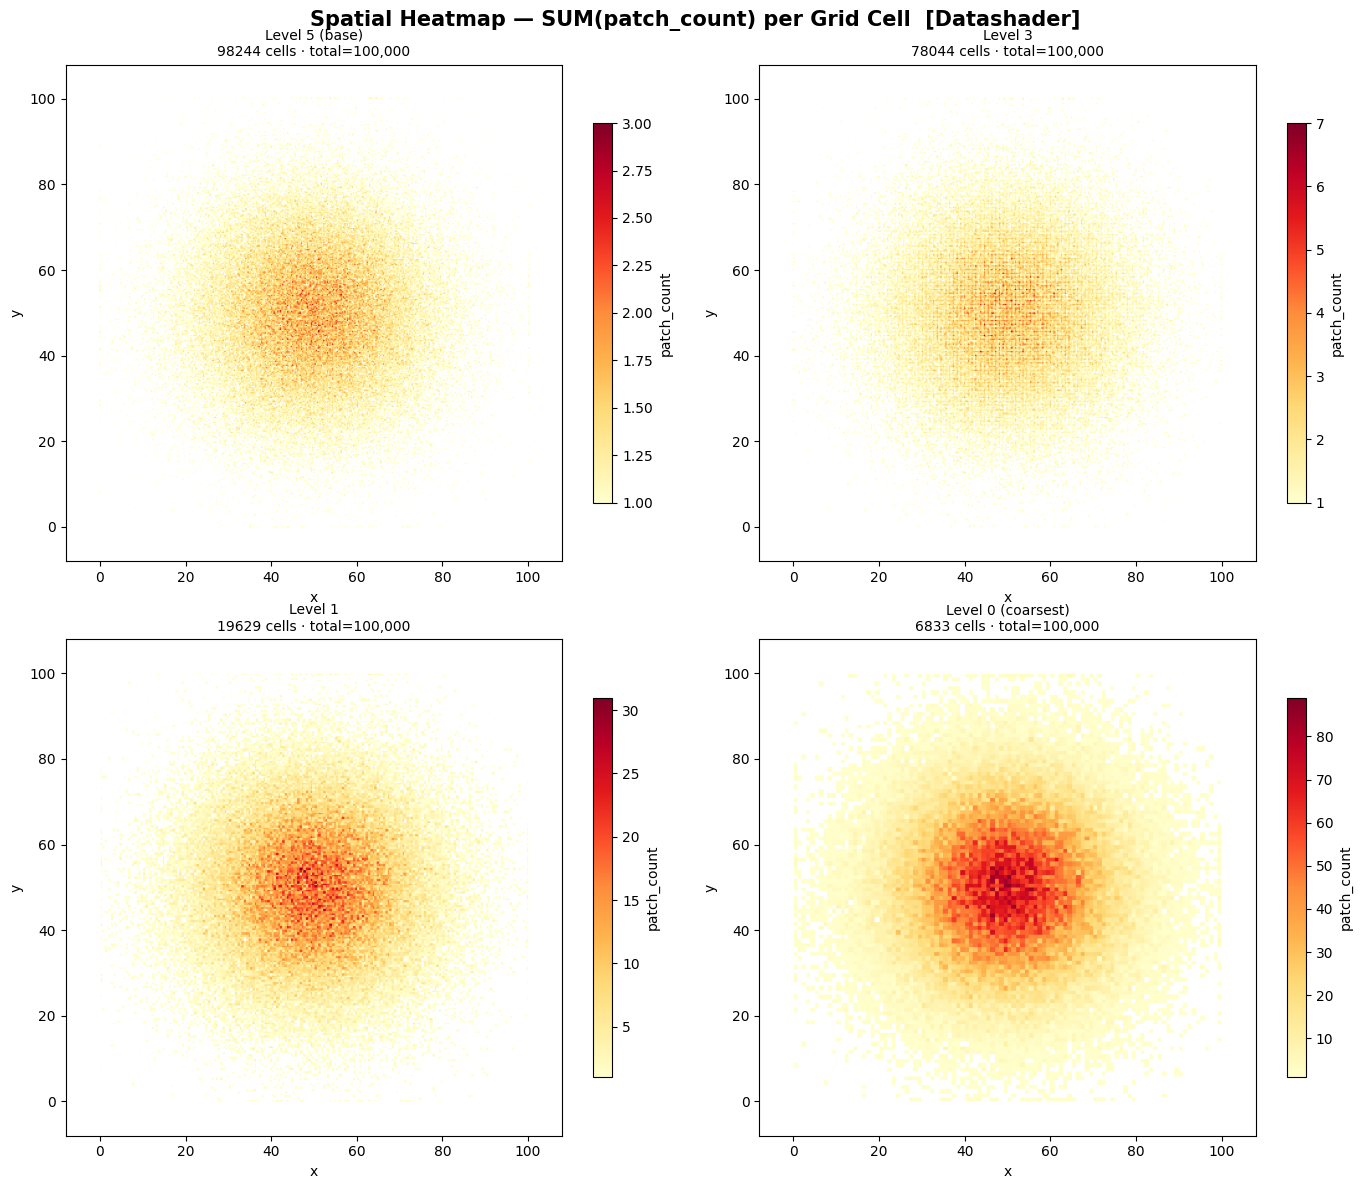

In [11]:

import datashader as ds
import datashader.transfer_functions as tf
from spatialpandas import GeoDataFrame
from spatialpandas.geometry import PolygonArray
import pandas as pd

# ── Helper: convert a cell_id to a closed polygon (xs, ys) ───────────────────
def cell_polygon(cell_id):
    """Return (xs, ys) lists for use with ax.fill / ax.plot."""
    pts = grid.cell_to_boundary(cell_id)   # returns closed polygon
    return [p[0] for p in pts], [p[1] for p in pts]

# ── Helper: compute axis bounds for a collection of cell_ids ─────────────────
def view_bounds(rows, pad_frac=0.08):
    all_pts = [pt for cell_id, _ in rows for pt in grid.cell_to_boundary(cell_id)]
    xs = [p[0] for p in all_pts]
    ys = [p[1] for p in all_pts]
    w  = max(xs) - min(xs) or grid.cell_size
    h  = max(ys) - min(ys) or grid.cell_size
    return (min(xs) - w * pad_frac, max(xs) + w * pad_frac,
            min(ys) - h * pad_frac, max(ys) + h * pad_frac)

# ── Helper: build a spatialpandas GeoDataFrame from (cell_id, count) rows ─────
def rows_to_geodataframe(rows):
    """Convert (cell_id, patch_count) rows → spatialpandas GeoDataFrame."""
    polys, counts = [], []
    for cell_id, count in rows:
        pts  = grid.cell_to_boundary(cell_id)   # [(x, y), …] closed ring
        flat = [c for pt in pts for c in pt]    # [x0, y0, x1, y1, …]
        polys.append([flat])                     # outer ring only, no holes
        counts.append(int(count))
    return GeoDataFrame({
        'geometry':    PolygonArray(polys),
        'patch_count': pd.array(counts, dtype='int64'),
    })

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — 2×2 Spatial Heatmap: patch_count per cell footprint  [Datashader]
# ══════════════════════════════════════════════════════════════════════════════
CANVAS_PX = 400   # pixel resolution per subplot

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Spatial Heatmap — SUM(patch_count) per Grid Cell  [Datashader]",
             fontsize=15, fontweight='bold')

for ax, (view, level, label) in zip(axes.flat, VIEWS):
    rows = spatial_data[view]
    if not rows:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
        continue

    x0, x1, y0, y1 = view_bounds(rows)
    gdf = rows_to_geodataframe(rows)

    # ── Rasterize polygons with datashader ────────────────────────────────────
    cvs = ds.Canvas(plot_width=CANVAS_PX, plot_height=CANVAS_PX,
                    x_range=(x0, x1), y_range=(y0, y1))
    agg = cvs.polygons(gdf, geometry='geometry', agg=ds.sum('patch_count'))
    img = tf.shade(agg, cmap=cm.YlOrRd, how='linear')
    img = tf.set_background(img, 'white')

    # ── Embed raster into the matplotlib subplot ──────────────────────────────
    rgba = np.array(img.to_pil())
    ax.imshow(rgba, extent=[x0, x1, y0, y1], origin='upper', aspect='equal')

    ax.set_title(f"{label}\n{len(rows)} cells · total={sum(r[1] for r in rows):,}",
                 fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # ── Colorbar (proxy ScalarMappable matched to the datashader range) ───────
    counts_list = [r[1] for r in rows]
    norm = mcolors.Normalize(vmin=min(counts_list), vmax=max(counts_list))
    sm   = cm.ScalarMappable(cmap=cm.YlOrRd, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.75, label='patch_count')

plt.tight_layout()
plt.show()


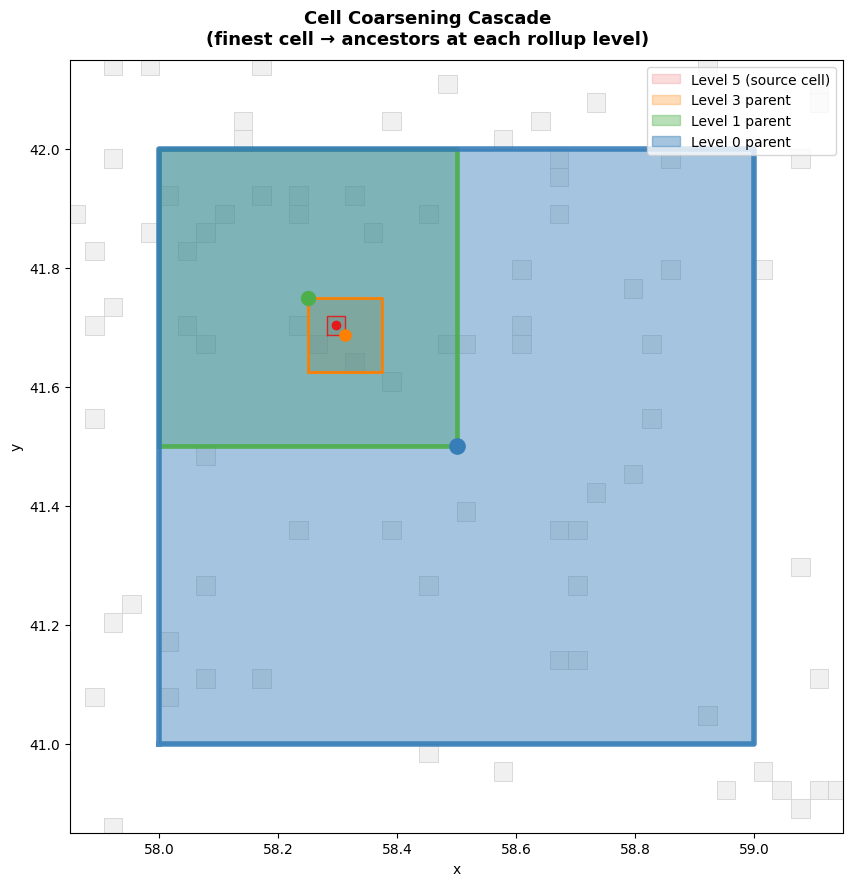

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — Coarsening Cascade: pick one level-5 cell and show its parent chain
# Overlays the level-3, level-1, and level-0 ancestor boundaries on top.
# ══════════════════════════════════════════════════════════════════════════════

# Pick the level-5 cell with the highest patch_count to make the cascade vivid
finest_rows = spatial_data["pred_patch_label_agg_l5"]
seed_cell   = max(finest_rows, key=lambda r: r[1])[0]

cascade_levels = [
    (seed_cell,                               5, "#e41a1c", "Level 5 (source cell)"),
    (grid.cell_to_parent(seed_cell, 3),       3, "#ff7f00", "Level 3 parent"),
    (grid.cell_to_parent(seed_cell, 1),       1, "#4daf4a", "Level 1 parent"),
    (grid.cell_to_parent(seed_cell, 0),       0, "#377eb8", "Level 0 parent"),
]

fig, ax = plt.subplots(figsize=(9, 9))
fig.suptitle("Cell Coarsening Cascade\n(finest cell → ancestors at each rollup level)",
             fontsize=13, fontweight="bold")

# Background: draw all level-5 cells in light grey so context is visible
for cell_id, _ in finest_rows:
    xs, ys = cell_polygon(cell_id)
    ax.fill(xs, ys, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.5)

# Overlay each ancestor with decreasing alpha so stacking is visible
for cell_id, level, color, label in cascade_levels:
    xs, ys = cell_polygon(cell_id)
    lw     = 1 + (5 - level) * 0.6          # thicker outline for coarser cells
    alpha  = 0.15 + (5 - level) * 0.06      # slightly more opaque for coarser
    ax.fill(xs, ys, color=color, alpha=alpha, label=label)
    ax.plot(xs, ys, color=color, linewidth=lw, alpha=0.9)
    # Mark the centroid
    cx, cy = grid.cell_to_point(cell_id)
    ax.plot(cx, cy, "o", color=color, markersize=6 + (5 - level))

# Set plot bounds based on the level-0 ancestor (coarsest = widest)
x0, x1, y0, y1 = view_bounds([(cascade_levels[-1][0], 1)], pad_frac=0.15)
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()


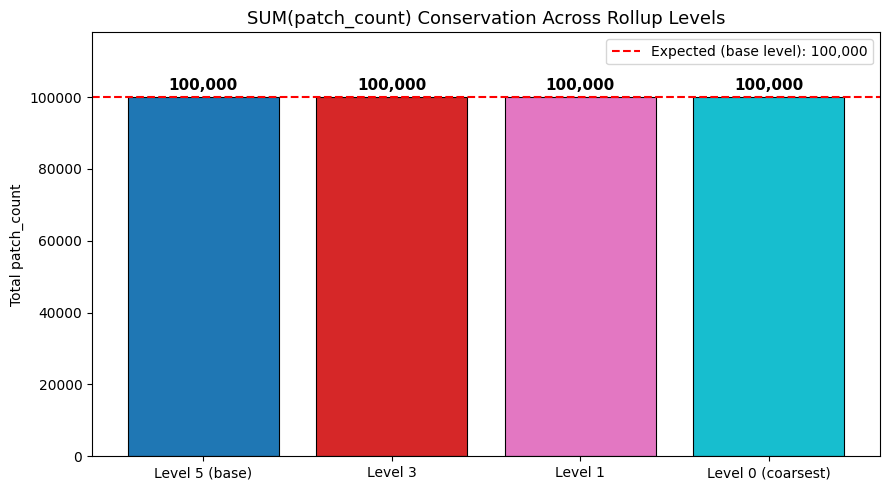

Visualizations complete.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — Conservation Bar Chart: same total at every level?
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))

bar_labels  = [label for _, _, label in VIEWS]
bar_totals  = [sum(r[1] for r in spatial_data[view]) for view, _, _ in VIEWS]
bar_colors  = plt.cm.tab10(np.linspace(0, 1, len(VIEWS)))
expected    = bar_totals[0]

bars = ax.bar(bar_labels, bar_totals, color=bar_colors, edgecolor="black", linewidth=0.8)
for bar, total in zip(bars, bar_totals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + expected * 0.01,
            f"{total:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(expected, color="red", linestyle="--", linewidth=1.5,
           label=f"Expected (base level): {expected:,}")
ax.set_title("SUM(patch_count) Conservation Across Rollup Levels", fontsize=13)
ax.set_ylabel("Total patch_count")
ax.set_ylim(0, max(bar_totals) * 1.18)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

_vis_cur.close()
_vis_conn.close()
print("Visualizations complete.")

## 8. Incremental Insert + Refresh

Insert **`M`** new rows into `patch` and `pred_patch`, then refresh each continuous aggregate
over only the **dirty time window** covered by the new data.

Key points:
- The dirty window is computed from the actual `event_ts` values of the inserted rows — no hardcoded interval.
- Each `CALL refresh_continuous_aggregate(view, start, end)` touches only the buckets that contain new data.
- Rollup propagates bottom-up: l5 → l3 → l1 → l0.

In [14]:
import math
import time
import numpy as np
import psycopg2
from datetime import datetime, timezone, timedelta
import sys
sys.path.insert(0, '/opt/PatchSorter/prototyping')
from utils import HierarchicalGridIndexZOrder

M = 500          # number of new rows to insert into each table
GRID_LEVEL = 5
grid = HierarchicalGridIndexZOrder(cell_size=1.0)

# ── Fresh connection ───────────────────────────────────────────────────────────
_inc_conn = psycopg2.connect(DATABASE_URL)
_inc_conn.autocommit = False
_inc_cur  = _inc_conn.cursor()

# ── Snapshot totals BEFORE insert ─────────────────────────────────────────────
CAGG_VIEWS = [
    "pred_patch_label_agg_l5",
    "pred_patch_label_agg_l3",
    "pred_patch_label_agg_l1",
    "pred_patch_label_agg_l0",
]
totals_before = {}
for view in CAGG_VIEWS:
    _inc_cur.execute(f"SELECT SUM(patch_count) FROM {view};")
    totals_before[view] = int(_inc_cur.fetchone()[0] or 0)
print("Totals BEFORE insert:")
for v, t in totals_before.items():
    print(f"  {v:<30}  {t:>10,}")

# ── 1. Insert M rows into patch ───────────────────────────────────────────────
_inc_cur.execute("SELECT MAX(patch_uid) FROM patch;")
uid_offset = _inc_cur.fetchone()[0] or 0

t0 = time.perf_counter()
_inc_cur.execute(f"""
    INSERT INTO patch (patch_uid, gt_label, event_ts, image_id, working_mag)
    SELECT
        {uid_offset} + gs                                    AS patch_uid,
        1                                                    AS gt_label,
        NOW() - (random() * INTERVAL '7 days')              AS event_ts,
        (gs % 10) + 1                                        AS image_id,
        CASE (gs % 3) WHEN 0 THEN 10.0 WHEN 1 THEN 20.0 ELSE 40.0 END AS working_mag
    FROM generate_series(1, {M}) AS gs;
""")
_inc_conn.commit()
print(f"\npatch   : {M:,} rows inserted in {time.perf_counter() - t0:.3f}s  (uid {uid_offset+1}–{uid_offset+M})")

# ── 2. Insert M rows into pred_patch ──────────────────────────────────────────
rng = np.random.default_rng(123)
ex  = np.clip(rng.normal(50.0, 15.0, M), 0.0, 99.9999)
ey  = np.clip(rng.normal(50.0, 15.0, M), 0.0, 99.9999)

grid_cell_ids_new = np.array([
    grid.point_to_cell(float(x), float(y), GRID_LEVEL)
    for x, y in zip(ex, ey)
], dtype=np.int64)

px_n = rng.uniform(0, 1000, M)
py_n = rng.uniform(0, 1000, M)
now  = datetime.now(timezone.utc)
# New rows spread over the last 7 days (same span as patch inserts above)
event_ts_new = [now - timedelta(seconds=rng.uniform(0, 7 * 24 * 3600)) for _ in range(M)]

new_rows = [
    (int(uid_offset + i + 1),
     f"({ex[i]},{ey[i]})",
     int(grid_cell_ids_new[i]),
     event_ts_new[i],
     1,                           # pred_label = 1 (single-class)
     f"({px_n[i]},{py_n[i]})")
    for i in range(M)
]

t0 = time.perf_counter()
_inc_cur.executemany("""
    INSERT INTO pred_patch (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    VALUES (%s, %s::point, %s, %s, %s, %s::point)
""", new_rows)
_inc_conn.commit()
print(f"pred_patch: {M:,} rows inserted in {time.perf_counter() - t0:.3f}s")

# ── 3. Compute dirty window ────────────────────────────────────────────────────
# Round down to the nearest 1-hour bucket boundary (matches the CAgg bucket width).
BUCKET_S = 3600

def floor_to_bucket(dt, bucket_s=BUCKET_S):
    ts = dt.timestamp()
    return datetime.fromtimestamp(math.floor(ts / bucket_s) * bucket_s, tz=timezone.utc)

window_start = floor_to_bucket(min(event_ts_new))
window_end   = max(event_ts_new) + timedelta(seconds=BUCKET_S)  # one full bucket of headroom

print(f"\nDirty window: {window_start}  →  {window_end}")

# ── 4. Incremental refresh — bottom-up across all levels ──────────────────────
_inc_conn.autocommit = True
print(f"\n{'View':<30}  {'refresh time (s)':>16}")
print("-" * 50)
for view in CAGG_VIEWS:
    t0 = time.perf_counter()
    _inc_cur.execute(
        "CALL refresh_continuous_aggregate(%s, %s, %s);",
        (view, window_start, window_end),
    )
    print(f"{view:<30}  {time.perf_counter() - t0:>16.3f}")
_inc_conn.autocommit = False

# ── 5. Verify totals grew by exactly M ────────────────────────────────────────
print(f"\n{'View':<30}  {'before':>10}  {'after':>10}  {'delta':>8}  {'ok':>4}")
print("-" * 70)
all_ok = True
for view in CAGG_VIEWS:
    _inc_cur.execute(f"SELECT SUM(patch_count) FROM {view};")
    after = int(_inc_cur.fetchone()[0] or 0)
    delta = after - totals_before[view]
    ok    = delta == M
    all_ok = all_ok and ok
    print(f"{view:<30}  {totals_before[view]:>10,}  {after:>10,}  {delta:>8,}  {'✓' if ok else '✗':>4}")

print(f"\n{'All levels grew by exactly M=' + str(M)}" if all_ok else f"\n⚠ Some levels did not grow by M={M}")

_inc_cur.close()
_inc_conn.close()


Totals BEFORE insert:
  pred_patch_label_agg_l5            100,000
  pred_patch_label_agg_l3            100,000
  pred_patch_label_agg_l1            100,000
  pred_patch_label_agg_l0            100,000

patch   : 500 rows inserted in 0.004s  (uid 100001–100500)
pred_patch: 500 rows inserted in 0.158s

Dirty window: 2026-02-26 23:00:00+00:00  →  2026-03-06 00:09:26.367373+00:00

View                            refresh time (s)
--------------------------------------------------
pred_patch_label_agg_l5                    0.900
pred_patch_label_agg_l3                   87.402
pred_patch_label_agg_l1                   68.769
pred_patch_label_agg_l0                   18.576

View                                before       after     delta    ok
----------------------------------------------------------------------
pred_patch_label_agg_l5            100,000     100,500       500     ✓
pred_patch_label_agg_l3            100,000     100,500       500     ✓
pred_patch_label_agg_l1            100